In [28]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from scipy.integrate import odeint

In [29]:
t, m, R, g, a, lm1, lm2, om = smp.symbols(r"t m R g a \lambda_1 \lambda_2 \omega", real=True)
r, the, phi = smp.symbols(r"r \theta \phi", cls=smp.Function)
r = r(t)
the = the(t)
phi = phi(t)

def dt(x):
    return smp.diff(x), smp.diff(smp.diff(x))

r_d, r_dd = dt(r)
the_d, the_dd = dt(the)
phi_d, phi_dd = dt(phi)

In [30]:
v = smp.Matrix([r_d, r*the_d])

In [31]:
I = m * (r * smp.cos(the))**2
T = 1/2 * m * v.dot(v) + 1/2 * I * om**2
U = m * g * r * smp.cos(the)
L = T - U
L

0.5*\omega**2*m*r(t)**2*cos(\theta(t))**2 - g*m*r(t)*cos(\theta(t)) + 0.5*m*(r(t)**2*Derivative(\theta(t), t)**2 + Derivative(r(t), t)**2)

In [32]:
def lagrange_eq(L, variables, R=0):
    lagrange_equations = []

    for q in variables:
        q_dot = smp.diff(q, t)
        LE = smp.diff(smp.diff(L, q_dot), t) - smp.diff(L, q) + smp.diff(R, q_dot)
        LE = LE.simplify()
        lagrange_equations.append(LE)
        
    return tuple(lagrange_equations)

In [33]:
LEr, LEthe = lagrange_eq(L, (r, the))

In [34]:
LEr

1.0*m*(-\omega**2*r(t)*cos(\theta(t))**2 + g*cos(\theta(t)) - r(t)*Derivative(\theta(t), t)**2 + Derivative(r(t), (t, 2)))

In [35]:
LEthe

m*(0.5*\omega**2*r(t)*sin(2*\theta(t)) - g*sin(\theta(t)) + 1.0*r(t)*Derivative(\theta(t), (t, 2)) + 2.0*Derivative(\theta(t), t)*Derivative(r(t), t))*r(t)

# Constraints

The constraint the disc stays anchored to the hoop. So the position $r$ is always equal to the sum of the two radiuses $R + l$.

$$ r = a $$
$$ r - a = 0 $$

In [36]:
system = smp.Matrix(
    [
        LEr + lm1,
        LEthe,
    ]
)
system

Matrix([
[                     \lambda_1 + 1.0*m*(-\omega**2*r(t)*cos(\theta(t))**2 + g*cos(\theta(t)) - r(t)*Derivative(\theta(t), t)**2 + Derivative(r(t), (t, 2)))],
[m*(0.5*\omega**2*r(t)*sin(2*\theta(t)) - g*sin(\theta(t)) + 1.0*r(t)*Derivative(\theta(t), (t, 2)) + 2.0*Derivative(\theta(t), t)*Derivative(r(t), t))*r(t)]])

Substitue the constraints

In [37]:
system = system.subs({r: a, r_d: 0, r_dd: 0, phi_dd: the_dd})
system

Matrix([
[\lambda_1 + 1.0*m*(-\omega**2*a*cos(\theta(t))**2 - a*Derivative(\theta(t), t)**2 + g*cos(\theta(t)))],
[      a*m*(0.5*\omega**2*a*sin(2*\theta(t)) + 1.0*a*Derivative(\theta(t), (t, 2)) - g*sin(\theta(t)))]])

In [38]:
the_dd_eq = smp.solve(system[1], the_dd)[0]
smp.Eq(the_dd, the_dd_eq).expand()

Eq(Derivative(\theta(t), (t, 2)), -\omega**2*sin(\theta(t))*cos(\theta(t)) + g*sin(\theta(t))/a)

We obtain that

$$ \ddot{\theta} = - \omega^2 \sin(\theta)\cos(\theta) + \frac{g}{a} \sin(\theta)$$

We can use the chain rule $\ddot{\theta} = \frac{d\dot{\theta}}{d\theta} \frac{d\theta}{dt} = \dot{\theta} \frac{d\dot{\theta}}{d\theta}$

$$ \int \dot{\theta} ~ d\dot{\theta} = \int \dots ~ d\theta $$

$$ \frac{1}{2}\dot{\theta}^2 = \dots + c $$

Solve for $c$, such that the intial conditions are $\theta = \dot{\theta} = 0$

In [39]:
the_d2 = smp.integrate(the_dd_eq.expand(), the)
# Comes from the other side
the_d2 = 2 * the_d2
the_d2

-\omega**2*sin(\theta(t))**2 - 2*g*cos(\theta(t))/a

In [40]:
c = the_d2.subs({the: 0})
c

-2*g/a

We can substitute $\dot{\theta}^2$ inside the $r$ equation.

In [41]:
lm1_eq = system[0].subs({the_d**2: the_d2 + c}).simplify()
lm1_eq

\lambda_1 + 1.0*m*(-2*\omega**2*a*cos(\theta(t))**2 + \omega**2*a + 3*g*cos(\theta(t)) + 2*g)

In [42]:
lm1_eq = smp.solve(lm1_eq, lm1)[0]
smp.Eq(lm1, lm1_eq)

Eq(\lambda_1, m*(-2.0*\omega**2*a*sin(\theta(t))**2 + \omega**2*a - 3.0*g*cos(\theta(t)) - 2.0*g))

In [43]:
om_eq = smp.solve(lm1_eq, om)[1]
om_eq

sqrt(g*(3.0*cos(\theta(t)) + 2.0)/(a*cos(2.0*\theta(t))))

Now we need to check for wich angular velocity $\omega$ the ball is in a stationary point.

We set the acceleration equal to zero $\ddot{\theta} = 0$.

In [44]:
smp.Matrix(smp.solve(the_dd_eq, the))

Matrix([
[                            0],
[                           pi],
[-acos(g/(\omega**2*a)) + 2*pi],
[        acos(g/(\omega**2*a))]])

The argument of the $\arccos(x)$ is bounded by $-1 < x < 1$

By soving the inequality we find that in order for a stationary point to exist $\omega$ must be $\omega > \sqrt{\frac{g}{a}} = \omega_0$.

# Solving the equation of motion

In [45]:
stationary_angle_f = smp.lambdify((g, a, om), smp.solve(the_dd_eq, the)[3])

In [46]:
dthedt_f = smp.lambdify(the_d, the_d)
ddtheddt_f = smp.lambdify((a, g, om, the, the_d), the_dd_eq)

In [47]:
def dSdt(S, t, a, g, om):
    the, the_d = S
    return [
        dthedt_f(the_d),
        ddtheddt_f(a, g, om, the, the_d),
    ]

In [ ]:
tf = 10
t_steps = 600
t = np.linspace(0, tf, t_steps)
a = 2
g = 9.8
om = 2.5

In [49]:
np.sqrt(g / a)

np.float64(2.2135943621178655)

In [50]:
s = odeint(dSdt, y0=[1, 2], t=t, args=(a, g, om))

the_t = s.T[0]
x_t = 0
y_t = a * np.sin(the_t)
z_t = a * np.cos(the_t)

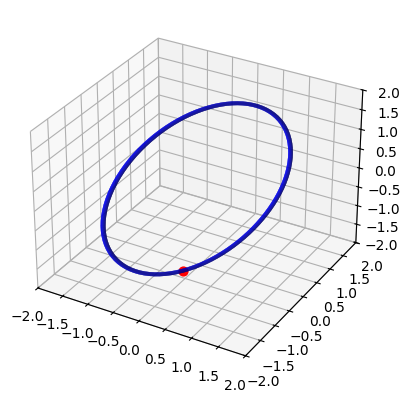

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.set_xlim((-a, a))
ax.set_ylim((-a, a))
ax.set_zlim((-a, a))

# Hoop
def hoop(rot_angle):
    t1 = np.linspace(0, 2*np.pi, 100)
    t2 = np.linspace(0, 2*np.pi, 100)
    t1, t2 = np.meshgrid(t1, t2)
    r = a / 50
    x = np.array([
        (a + r * np.sin(t1)) * np.cos(t2),
        (a + r * np.sin(t1)) * np.sin(t2),
        r * np.cos(t1),
    ])
    rot = np.array([
        [0, 0, 1],
        [0, 1, 0],
        [-1, 0, 0],
    ])
    z_rot = np.array([
        [np.cos(rot_angle), -np.sin(rot_angle), 0],
        [np.sin(rot_angle), np.cos(rot_angle), 0],
        [0, 0, 1],
    ])

    shape = x.shape
    x = (z_rot @ (rot @ x.reshape(3, -1))).reshape(shape)

    return x

def bead(f, rot_angle):
    bead = np.array([
        0,
        y_t[f],
        z_t[f],
    ])

    z_rot = np.array([
        [np.cos(rot_angle), -np.sin(rot_angle), 0],
        [np.sin(rot_angle), np.cos(rot_angle), 0],
        [0, 0, 1],
    ])

    return z_rot @ bead
    

x = hoop(0)
b = bead(0, 0)

hoop_ax = ax.plot_surface(*x)
bead_ax = ax.scatter(*b, color="red", s=40)
fps = int(t_steps / tf)

def update(f):
    global hoop_ax, bead_ax

    t = f / fps
    rot_angle = t * om

    hoop_ax.remove()
    hoop_ax = ax.plot_surface(*hoop(rot_angle), color="blue")

    bead_ax.remove()
    bead_ax = ax.scatter(*bead(f, rot_angle), color="red", s=40)

    return (
        hoop_ax,
        bead_ax,
    )


animation = anim.FuncAnimation(
    fig,
    update,
    frames=len(t),
    blit=True,
    interval=fps,
)

writer = anim.FFMpegWriter(fps=fps)
animation.save("bead-on-hoop.mp4", writer=writer)
# animation.save("bead-on-hoop.gif", writer=writer)

![image](./bead-on-hoop.gif)

# Plot a stationary point

In [52]:
s = odeint(dSdt, y0=[stationary_angle_f(g, a, om), 0], t=t, args=(a, g, om))

the_t = s.T[0]
z_t = a * np.cos(the_t)

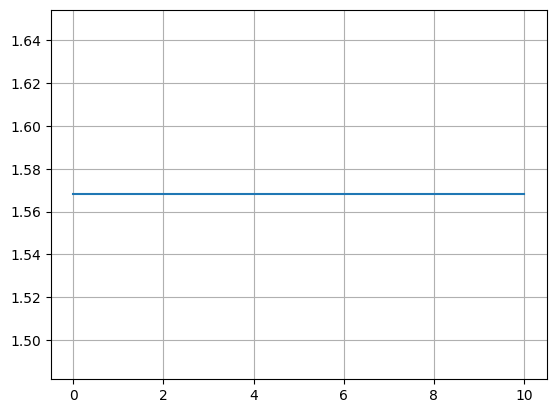

In [53]:
plt.grid()
plt.plot(t, z_t)